**<p style="text-align:center; font-size:30px"><u> Exercices de base numpy</u></p>**

In [2]:
import numpy as np
from scipy.stats import levy_stable, norm

import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation

from numpy.typing import ArrayLike
from typing import Tuple

# Exercice 1
- créez un numpy array depuis la liste suivante [11.7, 20, 325, 10.2, 11.7, 20]
- remplacez la première occurence de la valeur 11.7 par 5
- remplacez toutes les occurences des valeurs 20
- calculez la taille du tableau
- modifier le typage en uint8
- calculez la taille du tableau
- Observez les valeurs ? Que s'est-il passé ?

<br>

In [2]:
arr = np.array([11.7, 20, 325, 10.2, 11.7, 20])
arr[0] = 5

arr[arr == 20] = 0

print(arr.nbytes)

arr = arr.astype(np.uint8)
print(arr.nbytes)

arr

48
6


array([ 5,  0, 69, 10, 11,  0], dtype=uint8)

Le typage en uint 8 implique que le plage des valeurs ne peut s'étendre qu'entre 0 et 255. Toutes valeurs en dehors de cette plage ne génèrent pas d'erreur.

Elles sont ramenées entre les deux bornes à l'aide du modulo.

<br>

In [3]:
arr = np.array([384, 254, 798], dtype=np.int32)
display(arr.astype(np.uint8))
arr%256

array([128, 254,  30], dtype=uint8)

array([128, 254,  30], dtype=int32)

# Exercice 2

- créez un numpy array depuis la matrice suivante [[1, 2, 3],  [4, 5, 6], [7, 8, np.nan]]
- affichez:
  - le type de données de la matrice
  - sa forme
  - son nombre de dimension
  - son nombre d'élément
  - Depuis la forme, pouvez-vous obtenir le nombre de dimension et le nombre d'élément ?

<br>

In [4]:
arr = np.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, np.nan]])

print(f'dtype: {arr.dtype}\nshape: {arr.shape}\nndim: {arr.ndim}\nsize: {arr.size}')


dtype: float64
shape: (3, 3)
ndim: 2
size: 9


- multipliez la dernière colonne par 5 et divisez la première ligne par 0
- modifier le typage en int. Que se passe-t-il ?

<br>

In [5]:
arr[:, -1] = arr[:, -1]*5
arr[0] = arr[0]/0

display(arr)
arr = arr.astype(int)
arr.dtype

C:\Users\romain\AppData\Local\Temp\ipykernel_3076\3767207301.py:2: RuntimeWarning: divide by zero encountered in true_divide
  arr[0] = arr[0]/0


array([[inf, inf, inf],
       [ 4.,  5., 30.],
       [ 7.,  8., nan]])

dtype('int32')

np.nan ou np.inf sont toujours nécessairement stockés en float. Il n'est pas possible avec numpy de faire autrement. Nous le verrons plus tard mais Pandas par exemple coutourne cette contrainte.

<br>

- soit deux vecteurs représentant les notes(sur 20) en français d'une classe:
  ```py 
  [10, 15, 2, 10, 8]
  ```
  ```py 
  ['bob', 'alice', 'john', 'marie', 'pierre']
  ```
  - Affichez les noms des élèves en échec

<br>

In [6]:
notes = np.array([10, 15, 2, 10, 8])
students = np.array(['bob', 'alice', 'john', 'marie', 'pierre'])

students[notes < 10]

array(['john', 'pierre'], dtype='<U6')

# Exercice 3

- créez une matrice (4*4) remplie de valeurs aléatoires comprises entre 2 et 8

<br>

In [7]:
arr = np.random.randint(2, 8, (4, 4))

- créer un matrice d'identité (*i.e.* une matrice carrée dont la diagonale descendante principale est remplie de 1 et le reste = 0). Proposez plusieurs solutions

<br>

In [8]:
identity = np.zeros((5, 5), dtype=np.int32)
for i in range(identity.shape[0]):
    identity[i, i] = 1
identity

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1]])

In [9]:
identity = np.zeros((5, 5), dtype=np.int32)
# np.fill_diagonal does not return a view but is a in place operation
np.fill_diagonal(identity, 1)
identity

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1]])

In [10]:
# much faster
np.identity(5, dtype=np.int32)

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1]])

- créer une matrice dont la diagonale principale sera remplie de 6 valeurs aléatoires. Proposez plusieurs solutions

<br>

In [11]:
size = 6
diag = np.random.randint(0, 20, 6)
arr = np.zeros((size, size), dtype=np.int32)

for idx, val in np.ndenumerate(diag):
    arr[idx, idx] = val
arr

array([[18,  0,  0,  0,  0,  0],
       [ 0,  9,  0,  0,  0,  0],
       [ 0,  0, 15,  0,  0,  0],
       [ 0,  0,  0,  9,  0,  0],
       [ 0,  0,  0,  0,  6,  0],
       [ 0,  0,  0,  0,  0,  9]])

In [12]:
size = 6
diag = np.random.randint(0, 20, 6)
arr = np.zeros((size, size), dtype=np.int32)

np.fill_diagonal(arr, diag)
arr

array([[ 3,  0,  0,  0,  0,  0],
       [ 0, 18,  0,  0,  0,  0],
       [ 0,  0, 11,  0,  0,  0],
       [ 0,  0,  0, 15,  0,  0],
       [ 0,  0,  0,  0, 19,  0],
       [ 0,  0,  0,  0,  0, 13]])

# Exercice 4

- reproduire la matrice suivante (sans les noms de colonnes et d'index)
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>pâtes</th>
      <th>légumes</th>
      <th>divers</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>bob</th>
      <td>10€</td>
      <td>30€</td>
      <td>5€</td>
    </tr>
    <tr>
      <th>alice</th>
      <td>20€</td>
      <td>50€</td>
      <td>1€</td>
    </tr>
    <tr>
      <th>john</th>
      <td>15€</td>
      <td>30€</td>
      <td>NaN</td>
    </tr>
  </tbody>
</table>

- affichez le montant total des achats

<br>

In [13]:
arr = np.array([
    [10, 30, 5],
    [20, 50, 1],
    [15, 30, np.nan]
])
arr

array([[10., 30.,  5.],
       [20., 50.,  1.],
       [15., 30., nan]])

Les fonctions d'aggrégation ne sont pas par défaut *nan safe*. Si un ```np.nan``` est présent, la valeur renvoyée sera toujours ```np.nan```.

Deux solutions:
1. utilisez les versions *nan safe* des fonctions
2. dans notre cas, pour une somme, on peut remplacer par 0. Attention que si on fait une moyenne le résultat variera.

<br>

In [14]:
print(arr.sum())
print(np.nansum(arr))

nan
161.0


Il faut absolument utiliser la fonction np.isnan pour identifier les nan dans un numpy array et les modifier.

Autrement dit, la solution suivante ne fonctionne pas:

```py
arr[arr == np.nan]
```

<br>

In [15]:
arr[np.isnan(arr)] = 0

- affichez les totaux des achats par personne
- affichez les moyennes des achats par type d'aliment

<br>

In [16]:
print(np.nansum(arr, axis=1))
print(np.nansum(arr, axis=0))

[45. 71. 45.]
[ 45. 110.   6.]


# Exercice 5

Cette fois-ci nous avons les quantités achetées ainsi que le prix unitaire pour chacun des éléments

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>pâtes</th>
      <th>légumes</th>
      <th>divers</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>bob</th>
      <td>1</td>
      <td>4</td>
      <td>2</td>
    </tr>
    <tr>
      <th>alice</th>
      <td>3</td>
      <td>5</td>
      <td>7</td>
    </tr>
    <tr>
      <th>john</th>
      <td>5</td>
      <td>4</td>
      <td>4</td>
    </tr>
  </tbody>
</table>

```py
[20, 5, 3]
````

- calculez le montant total par personne

<br>

In [17]:
arr = np.array([
    [1, 4, 2],
    [3, 5, 7],
    [5, 4, 4]
])

price = np.array([20, 5, 3])

np.dot(arr, price)

array([ 46, 106, 132])

In [18]:
# slower
(arr*price).sum(axis=-1)

array([ 46, 106, 132])

- calculez le montant total par produit

<br>

In [19]:
np.einsum('i, ji->i', price, arr)

array([180,  65,  39])

In [20]:
np.einsum('ij, j->j', arr, price)

array([180,  65,  39])

**<p style="text-align:center; font-size:30px"><u> Exercices complémentaires numpy et matplotlib</u></p>**


# <u>[Fourmi de Langton](https://fr.wikipedia.org/wiki/Fourmi_de_Langton)</u>

Il s'agit d'un petit jeu aux règles simples qui s'apparente à un *snake*. Il s'agit de déplacer une fourmi sur un tableau en deux dimensions dont toutes les cases sont blanches au départ.

Les règles qui régissent les déplacements de la fourmi sont les suivantes(*cfr.* wiki):
- si la fourmi est sur une case noire, elle tourne de 90° vers la gauche, change la couleur de la case en blanc et avance d'une case.
- si la fourmi est sur une case blanche, elle tourne de 90° vers la droite, change la couleur de la case en noir et avance d'une case.

Vous devriez obtenir un résultat similaire à ceci:

<video width="600" height="600" controls src="static/ant.mp4" />


Si vous souhaitez approfondir le sujet, je recommande ce **[livre](https://www.vrin.fr/livre/9782711627707/quest-ce-que-lemergence)** pour débuter.


In [21]:
RULES = {
    0: (np.array((0, 1)), (2, 3)), 
    1: (np.array((0, -1)), (3, 2)), 
    2: (np.array((-1, 0)), (1, 0)), 
    3: (np.array((1, 0)), (0, 1))
}


def build_env(shape: int) -> Tuple[np.array, np.array, int]:
    """
    Create an environment for the ant represented by a 2D squared matrix. Ant is positionned at the center and a random
    value is generated to set his initial direction.

    Args:
        shape (int): shape of matrix

    Returns:
        Tuple[np.array, list, int]: the board, initial position and the direction
    """
    board = np.full((shape, shape), True)
    pos = np.full(2, shape/2, dtype=int)
    dir_ = np.random.randint(0, 4)

    return board, pos, dir_


# Probably much faster with recursive function and memoization than a for loop 
def move(board: np.array, pos: np.array, dir_: int) -> Tuple[np.array, np.array, int]:
    """
    Compute the next move of the ant and inverse the value of the matrix.

    Args:
        board (np.array): current board
        pos (np.array): current position
        dir_ (int): current direction

    Returns:
        Tuple[np.array, list, int]: board, pos and dir_ after the ant's move
    """
    old_pos = tuple(pos)
    rule, dir_ = RULES[dir_]

    if board[tuple(pos)]:
        dir_ = dir_[0]
        pos = pos + rule
    else:
        dir_ = dir_[1]
        pos = pos - rule

    board[old_pos] = ~board[old_pos]

    return board, pos, dir_


# TODO kwargs
def get_anim(shape: int = 200, max_step: int = 13000, dpi: int = 250, fps: int = 180) -> None:
    """
    Generates a mp4 file with all the move of the ant. Default parameter values ensure the ant 
    has enough step to build a highway.

    We do not use FuncAnim from matplotlib but instead we stack each matplotlib Artist(*i.e.* frame) 
    and then we render mp4 file with ArtistAnimation. FuncAnim might be faster.

    You need to set ffmpeg in your path or via plt.rcParams otherwise matplotlib use Pillow 
    and try to generate a GIF instead of a mp4.

    Args:
        shape (int, optional): _description_. Defaults to 200.
        max_step (int, optional): _description_. Defaults to 13000.
        dpi (int, optional): _description_. Defaults to 250.
        fps (int, optional): _description_. Defaults to 180.
    """
    board, pos, dir_ = build_env(shape)

    fig, ax = plt.subplots()
    fig.set_dpi(dpi)
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
    ax.imshow(board, cmap='gray')
    img = []

    for _ in range(max_step):
        board, pos, dir_ = move(board, pos, dir_)
        img.append([ax.imshow(board, cmap='gray', animated=True)])

    ani = ArtistAnimation(fig, img, interval=500, blit=True)
    ani.save('ant.mp4', fps=180)


## Sans animation

<br>

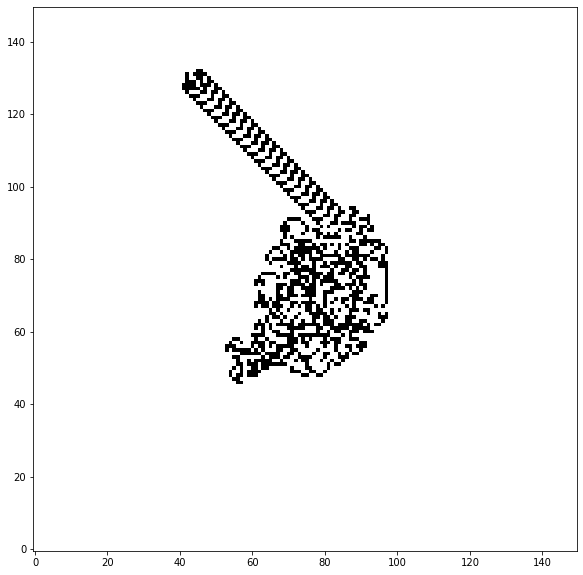

In [22]:
shape = 150
board, pos, dir_ = build_env(shape)
max_step = 12000

plt.figure(figsize=(10, 10))
for _ in range(max_step):
    board, pos, dir_ = move(board, pos, dir_)

plt.imshow(board, cmap='gray', origin='lower')
plt.show()   

## Avec animation

Vous devez télécharger [ffmpeg](https://ffmpeg.org/download.html) si vous souhaitez obtenir une vidéo plutôt qu'un rendu statique. Sans ffmpeg, matplotlib passe par Pillow pour en faire un gif ce qui posera problème avec > 10k images à afficher.

<br>

In [23]:
# get_anim() 

# Simulation d'un cours de bourse

Comment définir de manière simpliste mais suffisante pour l'exercice un cours de bourse:

1. un cours de bourse peut être modélisé pour une période(*timeframe*) donnée. Autrement dit, heure par heure, jour, semaine, *etc.*
2. en bourse, les valeurs des actions par exemple montent ou descendent, c'est ce que l'on appelle les accroissements. *A priori* il y a autant de chance qu'un cours monte ou descende pour une periode donnée. A noter aussi qu'à ce stade nous considérerons que les accroissements comme étant indépendants les uns des autres.
3. Il reste à déterminer de combien ces accroissements montent ou descendent. A ce stade nous considérerons qu'ils suivent une distribution normale.

<br>

## Première étape

Simulez un cours sans prendre en compte des accroissement qui seraient issus d'une distribution normale. Prenez des accroissements valant soit 1 ou -1 et afficher le graphique pour une période de temps donnée.

<br>

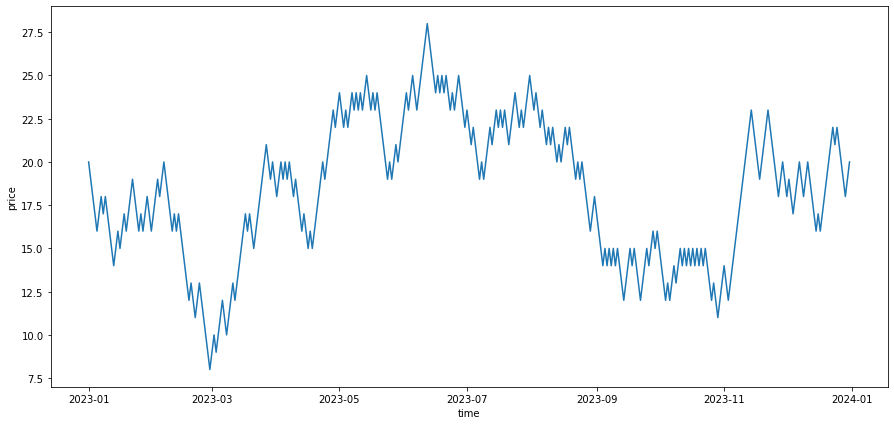

In [24]:
tf = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')
var = np.random.choice((-1, 1), tf.shape[0])

# starting price
var[0] = 20

plt.figure(figsize=(15, 7))
plt.plot(tf, var.cumsum())
plt.xlabel('time')
plt.ylabel('price')
plt.show()

Simulons plusieurs cours

<br>

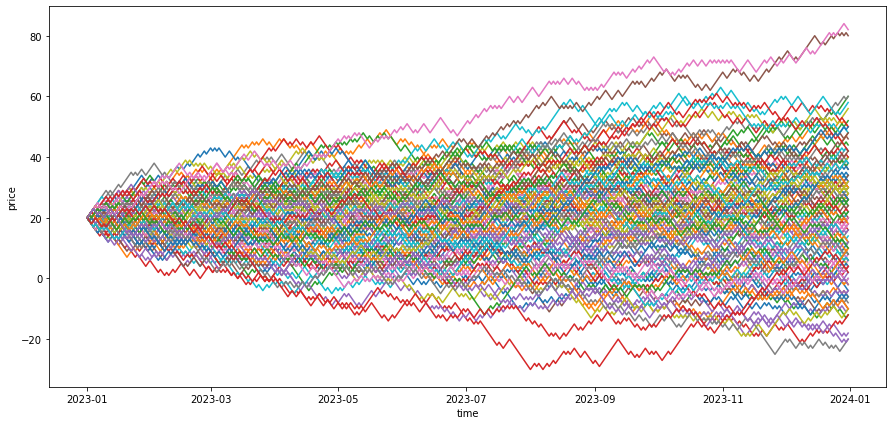

In [25]:
tf = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')

plt.figure(figsize=(15, 7))
plt.xlabel('time')
plt.ylabel('price')

for _ in range(125):
    var = np.random.choice((-1, 1), tf.shape[0])

    var[0] = 20
    plt.plot(tf, var.cumsum())


plt.show()




## Seconde étape

Cette fois ci, les accroissements seront issus d'une loi normale avec les paramètres de votre choix

<br>

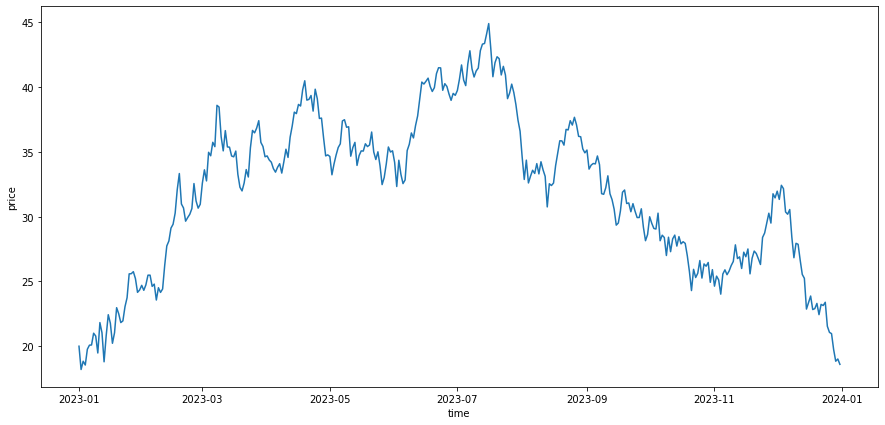

In [26]:
tf = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')

var = np.random.choice((-1, 1), tf.shape)
var = var*np.random.normal(0, 1, tf.shape[0])

var[0] = 20

plt.figure(figsize=(15, 7))
plt.plot(tf, var.cumsum())
plt.xlabel('time')
plt.ylabel('price')
plt.show()

# Bonus

Comme précédemment dit, il s'agit d'une modélisation très simplifiée mais vous pouvez améliorer certains éléments:

1. en fixant une borne inférieure au cours puisque nos cours peuvent être négatifs. 
2. en utilisant non pas une loi normale mais une loi leptokurtique (*e.g.* (loi stable)[https://fr.wikipedia.org/wiki/Loi_stable]). Elles ont pour particularité d'avoir des queues de distribution plus épaisses. Autrement dit, des accroissements extrêmes ont plus de probabilités de se produire.
3. il peut être intéressant de ne plus partir de l'hypothèse que les accroissements sont indépendants les uns des autres.
4. est-ce que la distribution des accroissements est toujours identique ?
5. *etc.*

<br>

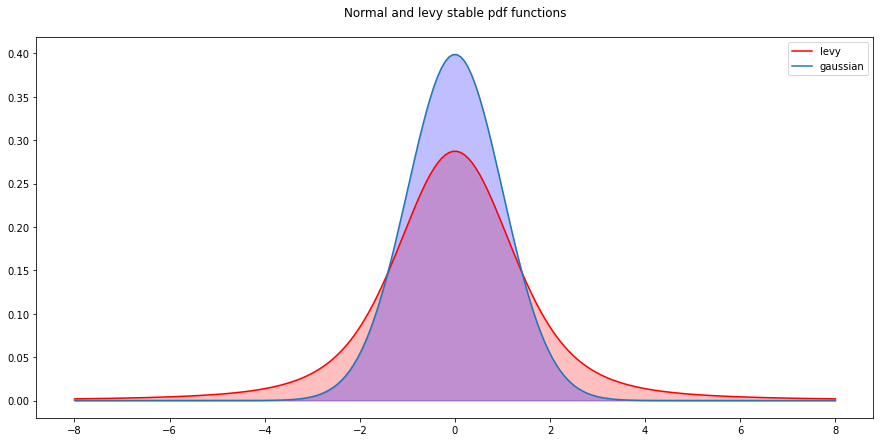

In [27]:
levy = levy_stable(alpha = 1.5, beta = 0)
normal = norm()

x = np.linspace(-8, 8, 200)
levy_pdf = levy.pdf(x)
norm_pdf = norm.pdf(x)

plt.figure(figsize=(15, 7))
plt.title('Normal and levy stable pdf functions\n')
plt.plot(x, levy_pdf, c='r', label='levy')
plt.plot(x, norm_pdf, label='gaussian')
plt.fill_between(x, levy_pdf, color='r', alpha=0.25)
plt.fill_between(x, norm_pdf, color='b', alpha=0.25)
plt.legend()
plt.show()

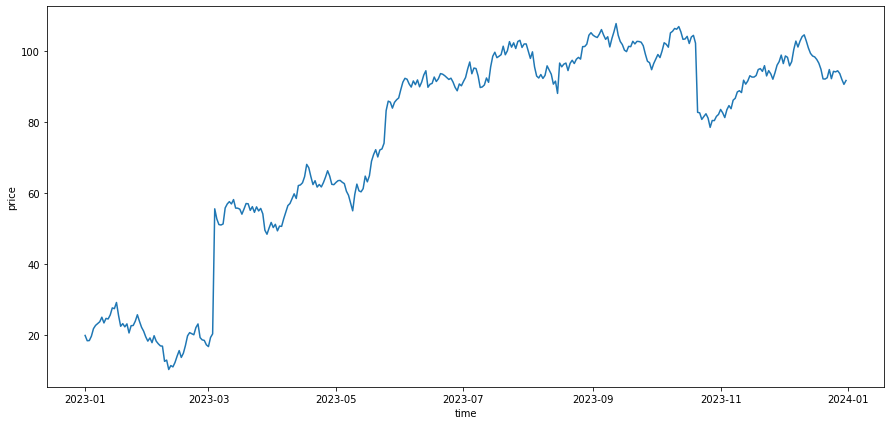

In [28]:
tf = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')

var = np.random.choice((-1, 1), tf.shape)
var = var*levy_stable.rvs(alpha=1.5, beta=0.9, size=tf.shape[0])

var[0] = 20

plt.figure(figsize=(15, 7))
plt.plot(tf, var.cumsum())
plt.xlabel('time')
plt.ylabel('price')
plt.show()